# (1) Introduction to Genetic Algorithm

**1. Nguồn gốc thuật toán GA**
- Một du khách muốn thăm những thành phố anh quan tâm; mỗi thành phố thăm qua đúng 1 lần; rồi trở về điểm khởi hành. Biết trước chi phí di chuyển giữa 2 thành phố bất kỳ 
- Ứng dụng trong Optimization, Lập kế hoạch,...
- Charles Darwin: Thuyết tiến hóa
    - Natural selection: 
        - Không thích nghi $\rightarrow$ chết
        - Cạnh tranh: Thức ăn, nơi ở, bạn tình
        - Thích nghi: Sinh sản, Đặc tính tích cực
    - Biodiversity:
        - Đa dạng loài
        - Quần thể đa dạng
    - Accumulation ò Small Changes (Đột biến)
    - Inheritance (Kế thừa)
    - Speciation (Hình thành loài)

**2. Thuật toán GA**
- Population Initialization: Khởi tạo quần thể
- Evaluation: Tính giá trị thích nghi
- Selection: Chọn lọc những cá thể thích nghi tốt
- Crossover: Lai ghép
- Mutation: Đột biến
- Stop ?
    - No: Quay lại Evaluation

# (2) Population

**1. Population là gì ?**
- Quần thể:
    - Tập hợp cá thể
    - Cùng loài
    - Cùng sinh sống trong không gian, thời gian
    - Có khả năng sinh sản thế hệ mới
    - Ví dụ: Rừng thông, ruộng lúa, quần thế voi,...
- Quần thể trong GA:
    - Tập hợp cá thể (individuals)
    - Biểu diễn các giải pháp trong không gian tìm kiếm
    - Mỗi cá thể là 1 giải pháp
    - Đặc trưng bởi kích thước, đa dạng, thay thế
    - Ví dụ: Quần thể 10 cá thể là chuỗi nhị phần dài 8 bit
        - [11001011, 1010100,....]
        - Đây là Chromosomes (Nhiễm sắc thể) và 1 phần tử trong nhiễm sắc thể là Gene (VD: 11001011 là Gene)

- Bài tập 1: Xác định population cho bài toán tối ưu hóa chuỗi nhị phần
    - Giả sử bạn muốn giải quyết bài toán tối ưu hóa chuỗi nhị phân dài 10 bit, trong đó ta cần tìm chuỗi nhị phân có tổng các bit là lớn nhất
    - Yêu cầu: Hãy viết một hàm có tên create_binary_population(pop_size, bit_length) nhận vào 2 tham số: pop_size (kích thước quần thể) và bit_length (độ dài của mỗi chuỗi nhị phân cá thể). Hàm này sẽ trả về một mảng Numpy biểu diễn quần thể gồm pop_size cá thể, mỗi cá thể là một chuỗi nhị phân có bit_length bit
    

In [3]:
import numpy as np
def create_binary_population(pop_size, bit_length):
    population = np.random.randint(2, size=(pop_size, bit_length))
    return population

In [2]:
pop_size = 20
bit_length = 10
population = create_binary_population(pop_size, bit_length)
print(population)

[[1 1 0 0 1 1 1 0 1 1]
 [0 1 0 1 0 0 1 1 0 0]
 [0 0 1 1 1 0 1 1 0 0]
 [1 0 1 1 1 0 0 0 0 0]
 [0 1 0 1 0 0 1 0 0 1]
 [1 1 1 1 0 0 1 1 0 0]
 [0 1 1 0 1 1 1 1 0 0]
 [1 0 1 1 1 1 1 0 1 1]
 [1 1 1 0 1 0 1 1 1 1]
 [0 0 1 1 0 0 0 1 1 1]
 [0 0 0 1 0 1 0 1 0 1]
 [0 1 1 1 1 1 1 0 1 1]
 [1 1 0 0 0 0 0 1 0 1]
 [0 0 1 1 0 1 1 0 0 1]
 [1 0 1 0 1 1 1 1 0 1]
 [1 0 1 0 0 1 0 0 0 1]
 [1 0 1 0 0 1 1 0 0 1]
 [1 1 0 0 1 1 1 0 0 0]
 [1 1 0 0 1 0 1 1 1 1]
 [1 1 1 1 1 0 0 0 1 0]]


# (2) Evaluation

- Tính fitness mỗi cá thể (Thể hiện mức sống của cá thể)
- Fitness value
    - Hiệu suất thể hiện độ tốt của mỗi cá thể
    - Tối ưu: Lớn nhất / Nhỏ nhất
- Mục tiêu
    - Xác định mức độ tốt của mỗi cá thể
    - Giúp lựa chọn cá thể thích nghi cao
    - Cá thể fitness cao -> thế hệ con tốt hơn
- Quá trình Evaluation
    - Xây dựng hàm fitness
    - Tính fitness từng cá thể
    - Gán fitness từng cá thể

- Bài tập 2: Tính fitness cho từng cá thể chuỗi nhị phân
    - Giả sử bạn muốn giải quyết bài toán tối ưu hóa chuỗi nhị phân dài 10 bit, trong đó ta cần tìm chuỗi nhị phân có tổng giá trị các bit là lớn nhất
    - Yêu cầu: Hãy viết một hàm có tên fitness_binary_individual(individual) nhận vào một tham số individual, đại diện cho một cá thể chuỗi nhị phân. Hàm này sẽ tính và trả về giá trị fitness của cá thể individual, dựa vào tổng số bit có giá trị 1 trong chuỗi nhị phân
    

In [14]:
def fitness_binary_individual(individual):
    fitness = np.sum(individual)
    return fitness

In [18]:
fitness_scores = []
for i in range(pop_size):
    score = fitness_binary_individual(population[i])
    print(f'Individual {i + 1}: {score}')
    fitness_scores.append(score)

Individual 1: 7
Individual 2: 4
Individual 3: 5
Individual 4: 4
Individual 5: 4
Individual 6: 6
Individual 7: 6
Individual 8: 8
Individual 9: 8
Individual 10: 5
Individual 11: 4
Individual 12: 8
Individual 13: 4
Individual 14: 5
Individual 15: 7
Individual 16: 4
Individual 17: 5
Individual 18: 5
Individual 19: 7
Individual 20: 6


# (3) Selection
- Chọn lọc cá thể trong quần thể dựa trên fitness
- Mục tiêu
    - Tạo tập hợp các cá thể fitness cao
    - Cơ hội lai ghép, đột biến cao
- Lựa chọn cá thể
    - fitness
    - selection probability
- Phương pháp
    - Roulette Wheel Selection: Ý tưởng từ bánh quay may mắn
        - B1: Tổng fitness quần thể
        - B2: Gán xác suất cá thể
        - B3: Chọn ngẫu nhiên cá thể
    - Tournament Selection: Sự tranh đấu cá thể
        - B1: Chọn ngẫu nhiên k cá thể
        - B2: Giữ lại cá thể fitness cao

- Bài tập 3:
    - Hãy viết một hàm có tên roulette_wheel_selection(population, fitness_values) nhận vào hai tham số: population (quần thể) và fitness_values (giá trị fitness tương ứng của từng cá thể trong quần thể). Hàm này sẽ thực hiện phương pháp lựa chọn cá thể trong quần thể dựa trên phương pháp Roulette Wheel Selection và trả về một mảng Numpy biểu diễn quần thể được lựa chọn

- Hàm np.random.choice(a, ...) có 2 cách cư xử dựa vào tham số đầu tiên a:
    - Cách 1: Nếu a là một danh sách (List/Array)
        - Nó sẽ chọn phần tử trực tiếp từ danh sách đó.
        - Ví dụ: np.random.choice(['Gà', 'Vịt', 'Heo']) $\rightarrow$ Trả về 'Vịt'.
    - Cách 2: Nếu a là một số nguyên (Integer) $\rightarrow$ Trường hợp ta đang dùng
        - Nó xem số nguyên n đó là giới hạn trên, và tự động tạo ra một dải số từ 0 đến n-1.
        - Ví dụ: np.random.choice(3) $\rightarrow$ Nó hiểu ngầm là chọn trong [0, 1, 2].

In [ ]:
import numpy as np

def roulette_wheel_selection(population, fitness_values):
    # 1. Tính tổng fitness
    total_fitness = np.sum(fitness_values)
    
    # 2. Tính xác suất chọn (Probability) cho từng cá thể
    # Công thức: P_i = Fitness_i / Tổng_Fitness
    probabilities = [i / total_fitness for i in fitness_values]
    
    # 3. Chọn ngẫu nhiên một index dựa trên trọng số (probabilities)
    # np.random.choice(a, p=...)
    # a: Danh sách các chỉ số để chọn (0, 1, 2, ..., n-1)
    # p: Danh sách xác suất tương ứng (Tổng p bắt buộc phải bằng 1)
    selected_index = np.random.choice(len(population),replace=False,p=probabilities)
    
    # 4. Trả về cá thể tại index đã chọn
    return population[selected_index]

In [27]:
selected_individual = roulette_wheel_selection(population, fitness_scores)
selected_individual

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 1], dtype=int32)

# (4) Crossover
- Lai ghép cha mẹ
    - Mô phỏng di truyền tự nhiên
    - Cá thể con kế thừa đặc tính
- ý nghĩa
    - Đa dạng trong quần thể
    - Giải pháp tiềm năng -> cá thể fitness cao
- Two-Point Crossover
    - Chọn 2 điểm chia từ cha mẹ
    - Trao điểm phần giữa 2 điểm chia -> 2 cá thể con


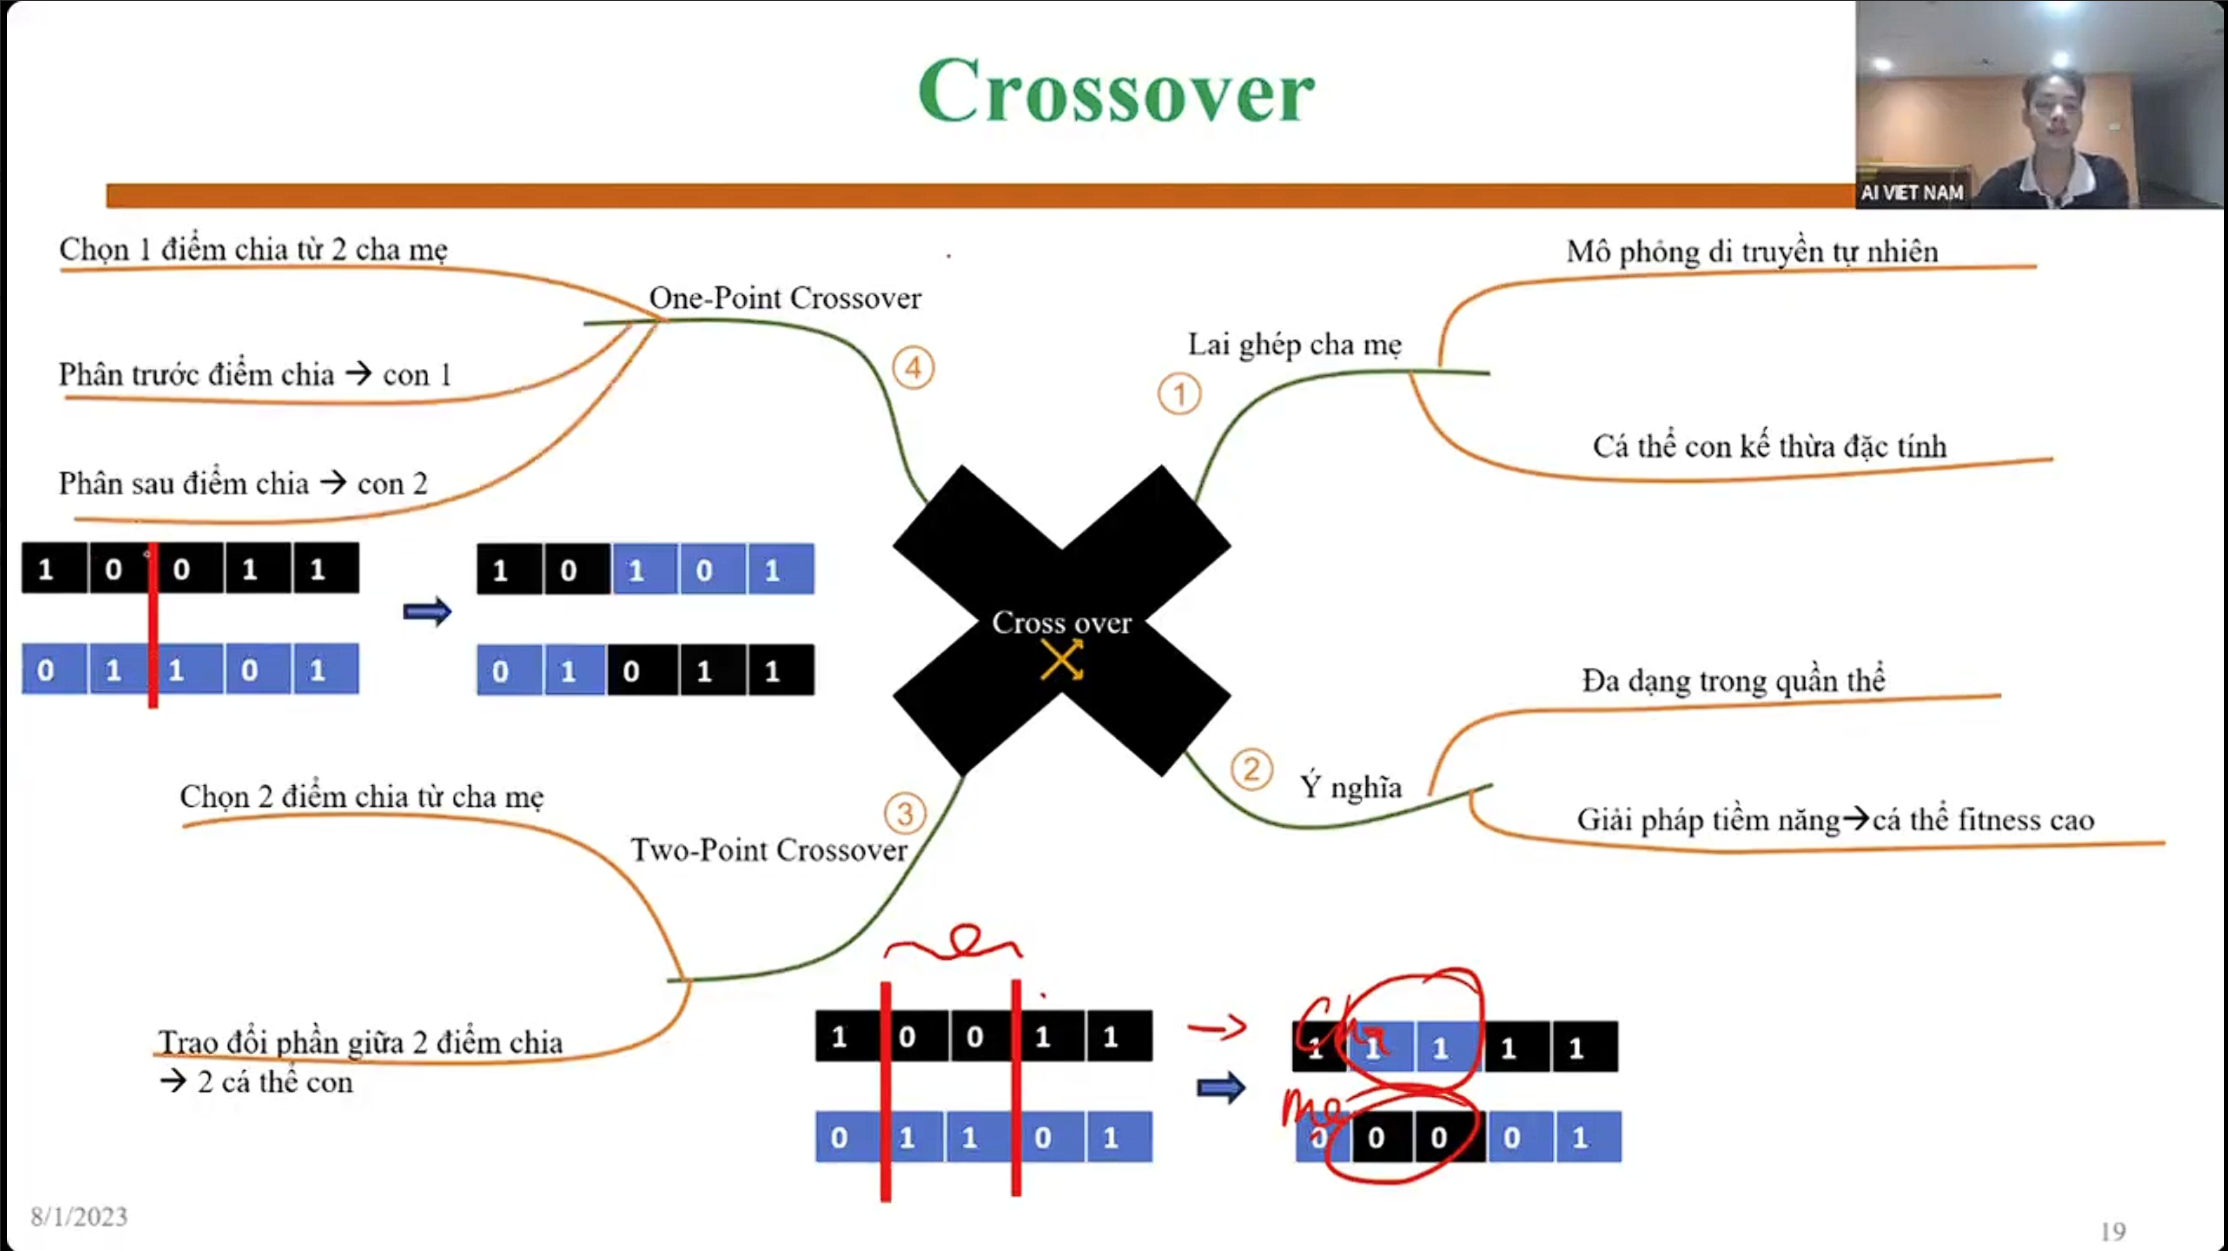

- Bài tập 4:
    - Hãy viết một hàm có tên one_point_crossover(parent1, parent2) nhận vào 2 tham số parent1 và parent2, đại diện cho hai cá thể cha mẹ. Hàm này sẽ thực hiện phép lai ghép One-Point Crossover giữa hai cá thể cha mẹ và trả về hai cá thể con mới tạo ra từ phép lai ghép này

In [79]:
def one_point_crossover(parent1, parent2):
    slice_index = np.random.randint(1, len(parent1) - 1)

    # Child1: Đầu Parent1 + Đuôi Parent2 
    child1 = np.concatenate((parent1[:slice_index], parent2[slice_index:]))
    
    # Child2: Đầu parent2 + Đuôi parent1
    child2 = np.concatenate((parent2[:slice_index], parent1[slice_index:]))
    return child1, child2

# (5) Mutation
- Ngẫu nhiên thay đổi 1 số gen trong cá thể -> cá thể mới
- Mục đích
    - Đa dạng quần thể
    - Mở rộng không gian giải pháp
- Mức đột biến (Mutation rate)
    - Xác suất gen bị thay đổi
    - Giá trị nhỏ: 0.01, 0.1... -> ít gene thay đổi
    - Giá trị lớn: 0.9, 1.0... -> nhiều gene thay đổi

- Phương pháp đảo bit (Bit-Flip mutation):
    - Chọn ngẫu nhiên gene
    - Nhị phân -> đảo ngược
    - Số thực -> đổi giá trị

- Đột biến đồng đều (Uniform mutation):
    - Chọn ngẫu nhiên gene
    - thay đổi giá trị từ khoảng cho trước

- Đột biến Gaussian:
    - Chọn ngẫu nhiên gene
    - Thay đổi giá trị theo phân phối chuẩn

- Bài tập 5: 
    - Hãy viết một hàm có tên bit_flip_mutation(individual, mutation_rate) nhận vào 2 tham số individual (cá thể chuỗi nhị phân) và mutation_rate (tỷ lệ đột biến). hàm này sẽ thực hiện phép đột biến cho cá thể individual, với xác suất đột biến là mutation_rate, và trả về cá thể mới sau khi đột biến

In [68]:
def bit_flip_mutation(individual, mutation_rate):
    for i in range(len(individual)):
        if np.random.random() < mutation_rate:
            if individual[i] == 0:
                individual[i] = 1
            else:
                individual[i] = 1
    return individual

In [72]:
child1 = population[-1]
print(child1)
mutation_child1 = bit_flip_mutation(child1, mutation_rate=0.5)
print(mutation_child1)

[1 1 1 1 1 0 0 0 1 1]
[1 1 1 1 1 1 1 1 1 1]


In [81]:
pop_size = 20
bit_length = 10

population = create_binary_population(pop_size, bit_length)

n = 100
score = []

for i in range(n):
    # 1. Tính fitness cho toàn bộ quần thể hiện tại
    fitnesses_score = np.apply_along_axis(fitness_binary_individual, 1, population)

    # Lưu lại điểm cao nhất để vẽ biểu đồ sau này
    score.append(max(fitnesses_score))
    print(f'Generation {i}: Best Fitness = {max(fitnesses_score)}')

    # 2. Tạo quần thể mới
    next_generation = []

    # Vì mỗi lần lai ghép tạo ra 2 con, ta chỉ cần lặp (pop_size / 2) lần
    for _ in range(int(pop_size/2)):

        # Selection: Chọn 2 con từ quần thể cũ
        parent1 = roulette_wheel_selection(population, fitnesses_score)
        parent2 = roulette_wheel_selection(population, fitnesses_score)

        # Crossover: Tạo 2 con
        child1, child2 = one_point_crossover(parent1, parent2)

        # Mutation: Đột biến 2 con
        new_child1 = bit_flip_mutation(child1, mutation_rate=0.1)
        new_child2 = bit_flip_mutation(child2, mutation_rate=0.1)

        # Thêm 2 con vào danh sách thế hệ mới
        next_generation.append(new_child1)
        next_generation.append(new_child2)

    # 3. Cập nhật quần thể
    population = np.array(next_generation)


Generation 0: Best Fitness = 8
Generation 1: Best Fitness = 9
Generation 2: Best Fitness = 10
Generation 3: Best Fitness = 9
Generation 4: Best Fitness = 9
Generation 5: Best Fitness = 9
Generation 6: Best Fitness = 10
Generation 7: Best Fitness = 10
Generation 8: Best Fitness = 10
Generation 9: Best Fitness = 10
Generation 10: Best Fitness = 10
Generation 11: Best Fitness = 10
Generation 12: Best Fitness = 10
Generation 13: Best Fitness = 10
Generation 14: Best Fitness = 10
Generation 15: Best Fitness = 10
Generation 16: Best Fitness = 10
Generation 17: Best Fitness = 10
Generation 18: Best Fitness = 10
Generation 19: Best Fitness = 10
Generation 20: Best Fitness = 10
Generation 21: Best Fitness = 10
Generation 22: Best Fitness = 10
Generation 23: Best Fitness = 10
Generation 24: Best Fitness = 10
Generation 25: Best Fitness = 10
Generation 26: Best Fitness = 10
Generation 27: Best Fitness = 10
Generation 28: Best Fitness = 10
Generation 29: Best Fitness = 10
Generation 30: Best Fitne

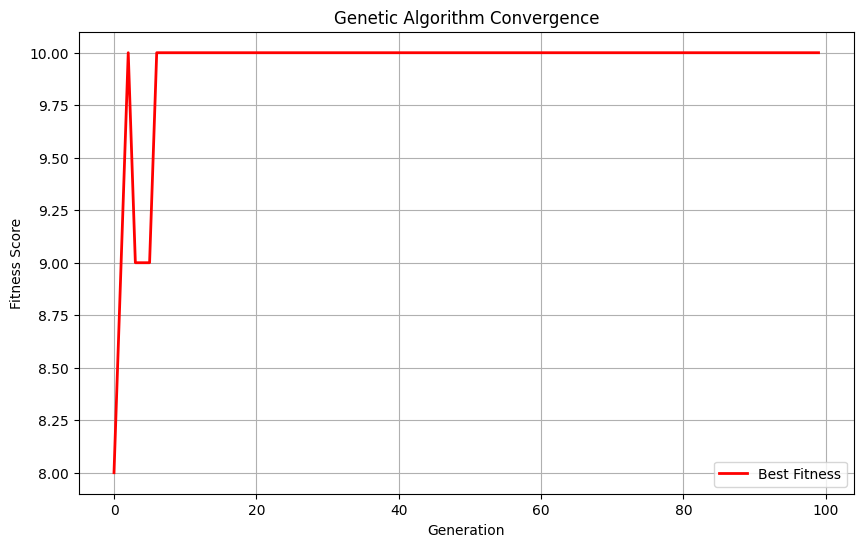

In [83]:
import matplotlib.pyplot as plt
# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(10, 6))
plt.plot(score, color='red', linewidth=2, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness Score')
plt.grid(True)
plt.legend()
plt.show()